# Breast Cancer Diagnosis with K-Nearest Neighbors (Euclidean Distance)

This notebook builds a binary classifier for the Wisconsin Diagnostic Breast Cancer dataset. It predicts `diagnosis` (`M` = malignant, `B` = benign) from numeric measurements of cell nuclei. The CSV also contains an `id` column, which is an identifier and is excluded from model features.

KNN classifies a sample by the labels of its nearest training samples. This notebook uses **Euclidean distance** and standardizes features because measurements have very different scales. All preprocessing is fit on training data only.

> Educational example only. This model is not a medical diagnostic tool.


## 1. Load the data

In Kaggle, add `Cancer_Data.csv` as a dataset input. The search below finds it under `/kaggle/input`; if running locally, set `CSV_PATH` to the downloaded file.

In [1]:
from pathlib import Path
import pandas as pd

CSV_PATH = None  # Optionally set to '/path/to/Cancer_Data.csv'
if CSV_PATH is None:
    candidates = list(Path('/kaggle/input').rglob('Cancer_Data.csv')) if Path('/kaggle/input').exists() else []
    if not candidates:
        candidates = list(Path('.').rglob('Cancer_Data.csv'))
    if not candidates:
        raise FileNotFoundError('Add Cancer_Data.csv as a Kaggle input or set CSV_PATH.')
    CSV_PATH = candidates[0]

df = pd.read_csv(CSV_PATH)
print(f'Shape: {df.shape}')
display(df.head())
print('Columns:', df.columns.tolist())

Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


## 2. Inspect and prepare the target

The source file has 569 rows and 32 columns: one ID, one diagnosis, and 30 numeric features (mean, standard error, and worst measurements). It has no precomputed chart bins/tables. We remove the ID, inspect missing values and class balance, then map `B` to 0 and `M` to 1. The median imputer later handles missing or nonnumeric feature values, including values that became missing during numeric conversion.

In [2]:
print('Missing values:', int(df.isna().sum().sum()))
print('Diagnosis counts:')
display(df['diagnosis'].value_counts().rename(index={'B':'Benign (B)', 'M':'Malignant (M)'}))

assert 'diagnosis' in df.columns
assert set(df['diagnosis'].dropna().unique()) <= {'B', 'M'}
X = df.drop(columns=['diagnosis', 'id'], errors='ignore').copy()
# Convert feature columns to numbers; malformed strings become missing values.
X = X.apply(pd.to_numeric, errors='coerce')
X = X.replace([float('inf'), float('-inf')], float('nan'))
# Remove columns that contain no usable numeric values at all.
empty_columns = X.columns[X.isna().all()].tolist()
if empty_columns:
    print('Dropping entirely empty feature columns:', empty_columns)
    X = X.drop(columns=empty_columns)
y = df['diagnosis'].map({'B': 0, 'M': 1})
if y.isna().any():
    raise ValueError('Unexpected or missing diagnosis labels found.')
print(f'Features: {X.shape[1]}')
print('Missing feature values after numeric conversion:', int(X.isna().sum().sum()))
print('Target encoding: 0 = benign (B), 1 = malignant (M)')

Missing values: 569
Diagnosis counts:


diagnosis
Benign (B)       357
Malignant (M)    212
Name: count, dtype: int64

Dropping entirely empty feature columns: ['Unnamed: 32']
Features: 30
Missing feature values after numeric conversion: 0
Target encoding: 0 = benign (B), 1 = malignant (M)


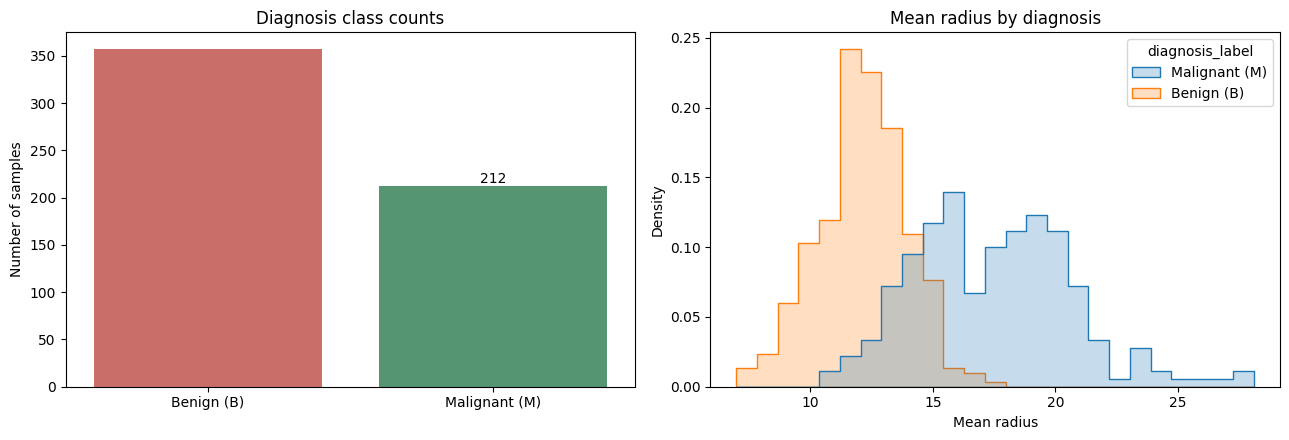

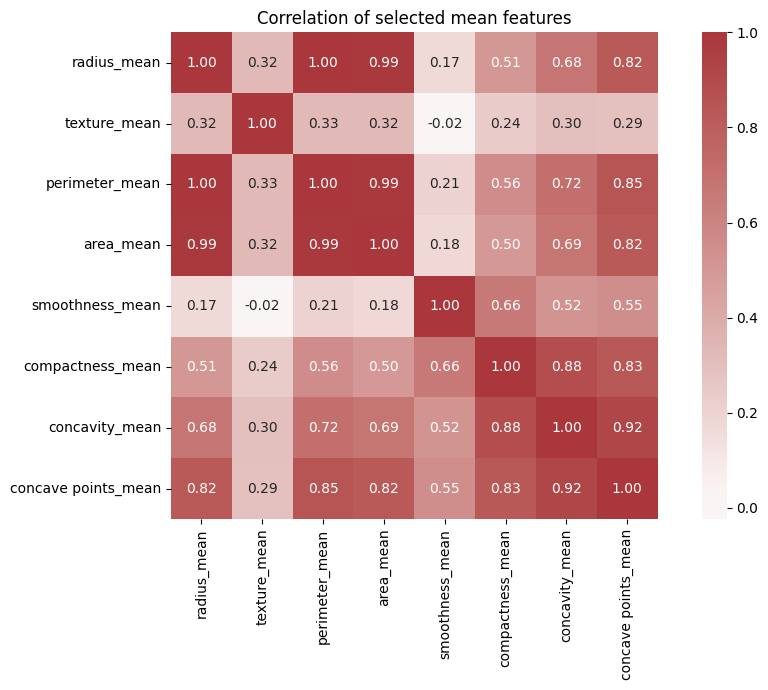

In [3]:
# Exploratory graphs: diagnosis balance and selected feature distributions
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df.copy()
plot_df['diagnosis_label'] = plot_df['diagnosis'].map({'B': 'Benign (B)', 'M': 'Malignant (M)'})
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(data=plot_df, x='diagnosis_label', order=['Benign (B)', 'Malignant (M)'], ax=axes[0], hue='diagnosis_label', legend=False, palette=['#4C9F70', '#D95F59'])
axes[0].set(title='Diagnosis class counts', xlabel='', ylabel='Number of samples')
axes[0].bar_label(axes[0].containers[0])
sns.histplot(data=plot_df, x='radius_mean', hue='diagnosis_label', bins=25, element='step', stat='density', common_norm=False, ax=axes[1])
axes[1].set(title='Mean radius by diagnosis', xlabel='Mean radius', ylabel='Density')
plt.tight_layout()
plt.show()

# Correlations among selected mean measurements
selected = [c for c in ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
                         'smoothness_mean', 'compactness_mean', 'concavity_mean',
                         'concave points_mean'] if c in X.columns]
plt.figure(figsize=(10, 7))
sns.heatmap(X[selected].corr(), cmap='vlag', center=0, annot=True, fmt='.2f', square=True)
plt.title('Correlation of selected mean features')
plt.tight_layout()
plt.show()

## 3. Hold out test data

A stratified split keeps the approximate benign/malignant proportions in both sets. The test set remains untouched during model selection.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print('Training rows:', len(X_train), '| Test rows:', len(X_test))

Training rows: 455 | Test rows: 114


## 4. Select the number of neighbors

We compare odd values of *k* using 5-fold stratified cross-validation on the training set. A pipeline ensures scaling is refit inside each fold, preventing preprocessing leakage. The model's metric is ROC AUC; it evaluates ranking performance across classification thresholds.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

k_values = [3, 5, 7, 9, 11, 15, 21]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
for k in k_values:
    candidate = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='uniform'))
    ])
    scores = cross_val_score(candidate, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results.append({'k': k, 'mean_roc_auc': scores.mean(), 'std_roc_auc': scores.std()})

cv_results = pd.DataFrame(cv_results).sort_values('mean_roc_auc', ascending=False)
display(cv_results)
best_k = int(cv_results.iloc[0]['k'])
print('Selected k:', best_k)

,k,mean_roc_auc,std_roc_auc
0,3,0.988700,0.013052
4,11,0.988648,0.011063
5,15,0.988132,0.009278
6,21,0.987874,0.009295
1,5,0.987100,0.013582
2,7,0.985965,0.014245
3,9,0.985501,0.013943


Selected k: 3


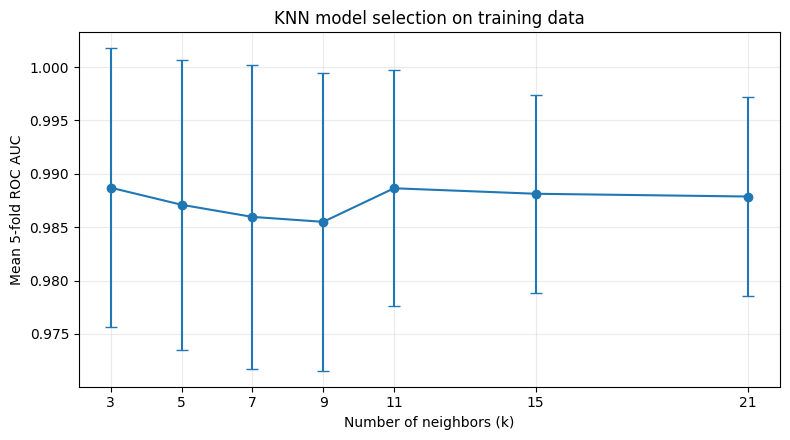

In [6]:
# Cross-validation performance for each neighbor count
ordered = cv_results.sort_values('k')
plt.figure(figsize=(8, 4.5))
plt.errorbar(ordered['k'], ordered['mean_roc_auc'], yerr=ordered['std_roc_auc'], marker='o', capsize=4)
plt.xlabel('Number of neighbors (k)')
plt.ylabel('Mean 5-fold ROC AUC')
plt.title('KNN model selection on training data')
plt.xticks(ordered['k'])
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Fit the final KNN classifier

Euclidean distance is computed on standardized features. For two feature vectors *x* and *z*, the distance is `sqrt(sum((xᵢ - zᵢ)²))`. The predicted class is the majority label among the `k` nearest training examples.

In [7]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)
import matplotlib.pyplot as plt

model = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', weights='uniform'))
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f'Accuracy:          {accuracy_score(y_test, y_pred):.3f}')
print(f'Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}')
print(f'Test ROC AUC:      {roc_auc_score(y_test, y_prob):.3f}')
print('\nClassification report (0 = benign, 1 = malignant):')
print(classification_report(y_test, y_pred, target_names=['Benign (B)', 'Malignant (M)']))

Accuracy:          0.939
Balanced accuracy: 0.922
Test ROC AUC:      0.982

Classification report (0 = benign, 1 = malignant):
               precision    recall  f1-score   support

   Benign (B)       0.92      0.99      0.95        72
Malignant (M)       0.97      0.86      0.91        42

     accuracy                           0.94       114
    macro avg       0.95      0.92      0.93       114
 weighted avg       0.94      0.94      0.94       114



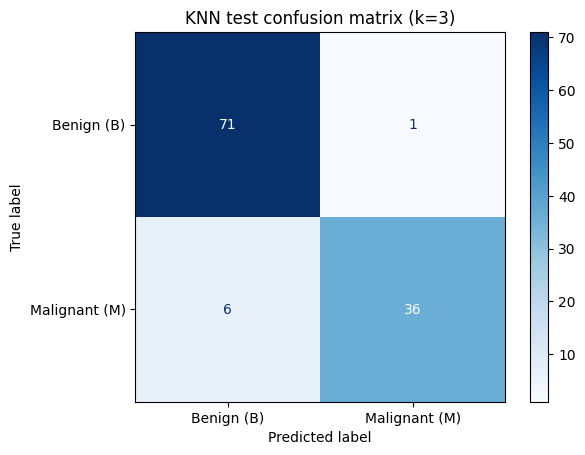

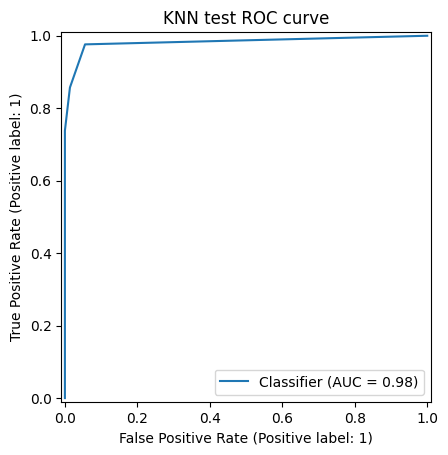

In [8]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=['Benign (B)', 'Malignant (M)']).plot(cmap='Blues', values_format='d')
plt.title(f'KNN test confusion matrix (k={best_k})')
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title('KNN test ROC curve')
plt.show()

## 6. Try an individual prediction

The example below uses one held-out case and displays its predicted class and the model's malignant probability. This probability is a model score, not a clinical risk estimate.

In [9]:
example = X_test.iloc[[0]]
predicted_label = model.predict(example)[0]
malignant_score = model.predict_proba(example)[0, 1]
print('Predicted diagnosis:', 'Malignant (M)' if predicted_label == 1 else 'Benign (B)')
print(f'Model malignant probability: {malignant_score:.3f}')

Predicted diagnosis: Benign (B)
Model malignant probability: 0.000


## 7. Takeaways and limitations

- The model uses 30 numeric nucleus measurements; `id` is excluded because it has no predictive meaning.
- Scaling matters: without it, large-unit features such as area can dominate Euclidean distance.
- Results depend on the split, selected *k*, and dataset. Review per-class metrics and the confusion matrix, especially false negatives.
- This is a learning exercise on a known dataset. It should not be used to diagnose or guide patient care.
